# TorchRL policy based RL

In this tutorial, we will learn how to use policy based RL algorithms. So far we've seen value based approaches, where the value of action+state combinations are learnt by our agents. This works well, but in cases where the action space is discrete it get's harder for these approaches to choose actions.

A policy based RL algorithm will build an explicity action model and use that model to help choose rewarding actions.

Let's first look at the REINFORCE algorithm!

* Note: this notebook was modified from the official tutorials provided by torchRL, you can check it out here: https://docs.pytorch.org/rl/stable/tutorials

### Install TorchRL

First let's install torchrl and tensordict.


In [1]:
#Option 1: easy
#If you are running this from colab you can run:
#!pip install tensordict
#!pip install torchrl

#Option 2: harder
#if you are using your own compputer you should create a virtual environment, activate it, and then use pip to install the needed 
#conda create -n torchrl-env python=3.11 -y
#conda activate torchrl-env
#pip install torchrl tensordict torch torchvision 'gymnasium[all]'
#Note: for GPU support this might be a little different, and might vary by device!

In [1]:
import torchvision 

from tensordict.nn import TensorDictSequential

import torch
from tensordict.nn import TensorDictModule
from tensordict import TensorDict
from torchrl.envs import GymEnv
from torch import nn

from torchrl.modules import QValueActor
from torch.optim import Adam
from torchrl.modules import QValueActor

### REINFORCE

A little history of reinforce algorithm.



#### Environment

In [4]:
from torchrl.envs import TransformedEnv, Compose, ObservationNorm, DoubleToFloat, StepCounter

#Let's build the pendulum env
base_env = GymEnv("Pendulum-v1")

#Let's do some transformations
env = TransformedEnv(
    base_env,
    Compose(
        # normalize observations
        ObservationNorm(in_keys=["observation"]),
        DoubleToFloat(),
        StepCounter(),
    ),
)

#Set the parameters for the normalization of the observations
env.transform[0].init_stats(num_iter=1000, reduce_dim=0, cat_dim=0)

As you may have noticed, we have created a normalization layer but we did not set its normalization parameters. To do this, ObservationNorm can automatically gather the summary statistics of our environment:

The ObservationNorm transform has now been populated with a location and a scale that will be used to normalize the data.

Let us do a little sanity check for the shape of our summary stats:

In [5]:
print("normalization constant shape:", env.transform[0].loc.shape)


normalization constant shape: torch.Size([3])


An environment is not only defined by its simulator and transforms, but also by a series of metadata that describe what can be expected during its execution. For efficiency purposes, TorchRL is quite stringent when it comes to environment specs, but you can easily check that your environment specs are adequate. In our example, the GymWrapper and GymEnv that inherits from it already take care of setting the proper specs for your environment so you should not have to care about this.

Nevertheless, let’s see a concrete example using our transformed environment by looking at its specs. There are three specs to look at: observation_spec which defines what is to be expected when executing an action in the environment, reward_spec which indicates the reward domain and finally the input_spec (which contains the action_spec) and which represents everything an environment requires to execute a single step.

In [6]:
print("observation_spec:", env.observation_spec)
print("reward_spec:", env.reward_spec)
print("input_spec:", env.input_spec)
print("action_spec (as defined by input_spec):", env.action_spec)

observation_spec: Composite(
    observation: BoundedContinuous(
        shape=torch.Size([3]),
        space=ContinuousBox(
            low=Tensor(shape=torch.Size([3]), device=cpu, dtype=torch.float32, contiguous=True),
            high=Tensor(shape=torch.Size([3]), device=cpu, dtype=torch.float32, contiguous=True)),
        device=cpu,
        dtype=torch.float32,
        domain=continuous),
    step_count: BoundedDiscrete(
        shape=torch.Size([1]),
        space=ContinuousBox(
            low=Tensor(shape=torch.Size([1]), device=cpu, dtype=torch.int64, contiguous=True),
            high=Tensor(shape=torch.Size([1]), device=cpu, dtype=torch.int64, contiguous=True)),
        device=cpu,
        dtype=torch.int64,
        domain=discrete),
    device=None,
    shape=torch.Size([]),
    data_cls=None)
reward_spec: UnboundedContinuous(
    shape=torch.Size([1]),
    space=ContinuousBox(
        low=Tensor(shape=torch.Size([1]), device=cpu, dtype=torch.float32, contiguous=True),
   

The check_env_specs() function runs a small rollout and compares its output against the environment specs. If no error is raised, we can be confident that the specs are properly defined:

In [7]:
from torchrl.envs import check_env_specs

check_env_specs(env)

2026-04-08 20:11:21,365 [torchrl][INFO]    check_env_specs succeeded! [END]


For fun, let’s see what a simple random rollout looks like. You can call env.rollout(n_steps) and get an overview of what the environment inputs and outputs look like. Actions will automatically be drawn from the action spec domain, so you don’t need to care about designing a random sampler.

Typically, at each step, an RL environment receives an action as input, and outputs an observation, a reward and a done state. The observation may be composite, meaning that it could be composed of more than one tensor. This is not a problem for TorchRL, since the whole set of observations is automatically packed in the output TensorDict. After executing a rollout (for example, a sequence of environment steps and random action generations) over a given number of steps, we will retrieve a TensorDict instance with a shape that matches this trajectory length:

In [8]:
rollout = env.rollout(3)
print("rollout of three steps:", rollout)
print("Shape of the rollout TensorDict:", rollout.batch_size)

rollout of three steps: TensorDict(
    fields={
        action: Tensor(shape=torch.Size([3, 1]), device=cpu, dtype=torch.float32, is_shared=False),
        done: Tensor(shape=torch.Size([3, 1]), device=cpu, dtype=torch.bool, is_shared=False),
        next: TensorDict(
            fields={
                done: Tensor(shape=torch.Size([3, 1]), device=cpu, dtype=torch.bool, is_shared=False),
                observation: Tensor(shape=torch.Size([3, 3]), device=cpu, dtype=torch.float32, is_shared=False),
                reward: Tensor(shape=torch.Size([3, 1]), device=cpu, dtype=torch.float32, is_shared=False),
                step_count: Tensor(shape=torch.Size([3, 1]), device=cpu, dtype=torch.int64, is_shared=False),
                terminated: Tensor(shape=torch.Size([3, 1]), device=cpu, dtype=torch.bool, is_shared=False),
                truncated: Tensor(shape=torch.Size([3, 1]), device=cpu, dtype=torch.bool, is_shared=False)},
            batch_size=torch.Size([3]),
            devic

Our rollout data has a shape of torch.Size([3]), which matches the number of steps we ran it for. The "next" entry points to the data coming after the current step. In most cases, the "next" data at time t matches the data at t+1, but this may not be the case if we are using some specific transformations (for example, multi-step).



In [9]:
rollout["action"]

tensor([[-0.3371],
        [-1.6518],
        [ 1.5819]])

#### Policy

So far our policies have estimated the value of state-actions, then we chose an action based on these estimated values. Usually though the choice of the max value action. Then to explore we added in some random choices sometimes.

Let's learn how to build a policy that directly models actions. That is, the policy based approach will e.g., take observations and output an action. We'll also see how to utilizes a stochastic policy to handle exploration. This means that our neural network will have to output the parameters of a distribution, rather than a single value corresponding to the action taken.

As the data is continuous, we use a Tanh-Normal distribution to respect the action space boundaries. TorchRL provides such distribution, and the only thing we need to care about is to build a neural network that outputs the right number of parameters for the policy to work with (a location, or mean, and a scale):

The only extra-difficulty that is brought up here is to split our output in two equal parts and map the second to a strictly positive space.

We design the policy in three steps:

1. Define a neural network D_obs -> 2 * D_action. Indeed, our loc (mu) and scale (sigma) both have dimension D_action.

2. Append a NormalParamExtractor to extract a location and a scale (for example, splits the input in two equal parts and applies a positive transformation to the scale parameter).

3. Create a probabilistic TensorDictModule that can generate this distribution and sample from it.

In [11]:
from torchrl.modules import NormalParamExtractor

num_cells = 32
device = "cpu"

actor_net = nn.Sequential(
    nn.LazyLinear(num_cells, device=device),
    nn.Tanh(),
    nn.LazyLinear(num_cells, device=device),
    nn.Tanh(),
    nn.LazyLinear(num_cells, device=device),
    nn.Tanh(),
    nn.LazyLinear(2 * env.action_spec.shape[-1], device=device),
    NormalParamExtractor(),
)

To enable the policy to “talk” with the environment through the tensordict data carrier, we wrap the nn.Module in a TensorDictModule. This class will simply ready the in_keys it is provided with and write the outputs in-place at the registered out_keys.

In [12]:
policy_module = TensorDictModule(
    actor_net, in_keys=["observation"], out_keys=["loc", "scale"]
)

We now need to build a distribution out of the location and scale of our normal distribution. To do so, we instruct the ProbabilisticActor class to build a TanhNormal out of the location and scale parameters. We also provide the minimum and maximum values of this distribution, which we gather from the environment specs.

The name of the in_keys (and hence the name of the out_keys from the TensorDictModule above) cannot be set to any value one may like, as the TanhNormal distribution constructor will expect the loc and scale keyword arguments. That being said, ProbabilisticActor also accepts Dict[str, str] typed in_keys where the key-value pair indicates what in_key string should be used for every keyword argument that is to be used.

In [13]:
from torchrl.modules import ProbabilisticActor, TanhNormal

policy_module = ProbabilisticActor(
    module=policy_module,
    spec=env.action_spec,
    in_keys=["loc", "scale"],
    distribution_class=TanhNormal,
    distribution_kwargs={
        "low": env.action_spec_unbatched.space.low,
        "high": env.action_spec_unbatched.space.high,
    },
    return_log_prob=True,
)



Let's see how we might use this type of policy and how it might learn from interacting with the environment.

First let's get some data from agent-environment interactions

In [14]:
#agent-environment interactions!
rollout = env.rollout(max_steps=10, policy=policy_module)

#collect the data
obs    = rollout["observation"]
act    = rollout["action"]
next_obs = rollout["next", "observation"]
reward = rollout["next", "reward"].squeeze(-1)
done   = rollout["next", "done"].squeeze(-1).float()

Let's see what the agent sees

In [15]:
obs

tensor([[1.4770, 0.1989, 0.0180],
        [1.4686, 0.2425, 0.0526],
        [1.4557, 0.2969, 0.0929],
        [1.4363, 0.3638, 0.1402],
        [1.4073, 0.4448, 0.1963],
        [1.3643, 0.5413, 0.2629],
        [1.3011, 0.6543, 0.3420],
        [1.2095, 0.7830, 0.4357],
        [1.0787, 0.9244, 0.5460],
        [0.8960, 1.0705, 0.6743]])

And take a look at what action is choose to use

In [16]:
act

tensor([[0.1845],
        [0.1835],
        [0.1819],
        [0.1794],
        [0.1758],
        [0.1706],
        [0.1632],
        [0.1525],
        [0.1369],
        [0.1138]], grad_fn=<StackBackward0>)

Remember that this policy is stochastic, let's see how it can explore actions using the loc and the scale parameters

In [17]:
from torchrl.envs.utils import ExplorationType, set_exploration_type

with set_exploration_type(ExplorationType.RANDOM):
    currrent_observations = TensorDict({"observation": obs}, batch_size=[obs.shape[0]])
    current_action = policy_module(currrent_observations) #calculate action
    print(current_action["action"])

tensor([[ 1.7747],
        [-1.8712],
        [ 1.3892],
        [ 1.5641],
        [ 0.3086],
        [ 1.5511],
        [-0.0334],
        [-0.9238],
        [-1.7690],
        [-0.3162]], grad_fn=<AddBackward0>)


In [18]:
print(current_action["loc"])

tensor([[0.0925],
        [0.0920],
        [0.0912],
        [0.0900],
        [0.0881],
        [0.0855],
        [0.0818],
        [0.0764],
        [0.0686],
        [0.0569]], grad_fn=<SplitBackward0>)


In [19]:
print(current_action["scale"])

tensor([[0.8192],
        [0.8203],
        [0.8218],
        [0.8238],
        [0.8265],
        [0.8301],
        [0.8350],
        [0.8416],
        [0.8505],
        [0.8623]], grad_fn=<ClampMinBackward0>)


#### Learning

How can such a policy based algorithm learn? 

Let's strat off by calculating the discounted return


In [20]:

def compute_returns(rewards, dones, gamma=0.99):
    returns = torch.zeros_like(rewards)
    R = 0
    for t in reversed(range(len(rewards))):
        if dones[t]:
            R = 0  # reset at episode boundary
        R = rewards[t] + gamma * R
        returns[t] = R
    return returns

returns = compute_returns(reward, done)
returns

tensor([-5.5397, -5.5442, -5.5200, -5.4526, -5.3205, -5.0923, -4.7222, -4.1439,
        -3.2623, -1.9430])

So this gives us the return at each state, based on the discouted rewards of the next state observed.

In [21]:
# Forward pass to get log probs

currrent_observations = TensorDict({"observation": obs}, batch_size=[obs.shape[0]])
policy_output = policy_module(currrent_observations) #calculate action

#policy_output = policy_module(batch)
log_probs = policy_output["action_log_prob"].squeeze()
log_probs

tensor([-1.4041, -1.4055, -1.4075, -1.4102, -1.4137, -1.4186, -1.4251, -1.4338,
        -1.4455, -1.4607], grad_fn=<SqueezeBackward0>)

Then we might want to calculate the loss so as to make actions that lead to more rewarding outcomes more likely. 

We can do this by getting the log probability of all the actions taken (log(prob=1)=0), and the discounted rewards at each action. Once we have those two things we can scale the rewards by the log probability of the action, -(log_p * G_t), so that large negative numbers * large rewards results in a high loss (i.e., a low probability action lead to a high reward) and should be adjusted a lot. While a log probability close to zero with a large reward shouldn't need to be updated a lot. 

Let's calculate that loss below:

In [22]:
loss = -(log_probs * returns)
loss

tensor([-7.7782, -7.7926, -7.7695, -7.6890, -7.5217, -7.2237, -6.7294, -5.9416,
        -4.7155, -2.8382], grad_fn=<NegBackward0>)

Let's put this all in practice now by implementing the REINFRORCE algorithm.

### Manually implement the REINFORCE algorithm

#### Data Collector

In [28]:
returns



tensor([-6.3426e-01, -6.5891e-01, -6.8276e-01, -7.0579e-01, -7.2736e-01,
        -7.4608e-01, -7.6125e-01, -7.7209e-01, -7.7675e-01, -7.7412e-01,
        -7.6337e-01, -7.4307e-01, -7.1134e-01, -6.6711e-01, -6.2424e-01,
        -5.9201e-01, -5.6951e-01, -5.5685e-01, -5.5236e-01, -5.5476e-01,
        -5.6298e-01, -5.7564e-01, -5.9107e-01, -6.0804e-01, -6.2527e-01,
        -6.4155e-01, -6.5597e-01, -6.6690e-01, -6.7287e-01, -6.7173e-01,
        -6.6235e-01, -6.4327e-01, -6.1208e-01, -5.6789e-01, -5.2441e-01,
        -4.9055e-01, -4.6650e-01, -4.5148e-01, -4.4444e-01, -4.4539e-01,
        -4.5199e-01, -4.6317e-01, -4.7853e-01, -4.9694e-01, -5.1671e-01,
        -5.3709e-01, -5.5749e-01, -5.7681e-01, -5.9337e-01, -6.0727e-01,
        -6.1522e-01, -6.1664e-01, -6.1085e-01, -5.9691e-01, -5.7266e-01,
        -5.3754e-01, -4.9153e-01, -4.5121e-01, -4.2093e-01, -4.0030e-01,
        -3.8865e-01, -3.8462e-01, -3.8682e-01, -3.9300e-01, -4.0217e-01,
        -4.1281e-01, -4.2374e-01, -4.3381e-01, -4.4

In [33]:
from torchrl.collectors import SyncDataCollector
from torchrl.data import LazyTensorStorage, ReplayBuffer, SamplerWithoutReplacement

frames_per_batch = 1000
total_frames = 1_000_000
lr=0.0001


collector = SyncDataCollector(
    env,
    policy_module,
    frames_per_batch=frames_per_batch,
    total_frames=total_frames,
    split_trajs=False,
    device=device,
)


optim = Adam(policy_module.parameters(), lr=lr)


loss_over_time = []

#agent-environment interactions!
for data in collector:
    
    #collect the data
    reward = data["next", "reward"].squeeze(-1)
    done   = data["next", "done"].squeeze(-1).float()

    # get discounted returns observed
    returns = compute_returns(reward, done)
    
    print(f"Raw returns: min={returns.min():+.3f} max={returns.max():+.3f} mean={returns.mean():+.3f}")
    
    returns = (returns - returns.mean()) / (returns.std() + 1e-8) #for stability it sometimes helps to normalize the returns (i.e., positive returns are higher than the average of 0... etc)

    # Get the log probs of the actions actually taken
    dist = policy_module.get_dist(data) #get the tanhnormal distribution
    log_probs = dist.log_prob(data["action"]).squeeze() #see where the action falls in terms of tanhnormal
    
    entropy = -log_probs.mean()
    loss = -(log_probs * returns).mean() - 0.01 * entropy


    #calculate the mean loss of observations 
    #loss = -(log_probs * returns).mean()

    #let's now optimize the model used to estimate q-values
    optim.zero_grad(set_to_none=True) #make sure everything gets set to zero before backprob..
    loss.backward() #backprop!
    torch.nn.utils.clip_grad_norm_(policy_module.parameters(), max_norm=0.50)
    optim.step()


    #let's keep track of the loss over time
    loss_over_time.append(loss.item())

    print(
        f"Batch {collector._frames // frames_per_batch:4d} | "
        f"Reward: {reward.mean().item():+7.3f} | "
        f"Actor Loss: {loss.item():+7.3f}  | "
        f"entropy Loss: {entropy.item():+7.3f}  | "
        f"returns: {returns.mean().item():.3f}"
    )




Raw returns: min=-741.497 max=-6.515 mean=-416.654
Batch    1 | Reward:  -7.233 | Actor Loss:  +0.030  | entropy Loss:  +0.720  | returns: 0.000
Raw returns: min=-733.062 max=-2.492 mean=-360.235
Batch    2 | Reward:  -6.196 | Actor Loss:  +0.067  | entropy Loss:  +0.844  | returns: -0.000
Raw returns: min=-787.945 max=-6.160 mean=-391.985
Batch    3 | Reward:  -6.871 | Actor Loss:  +0.113  | entropy Loss:  +0.755  | returns: -0.000
Raw returns: min=-659.362 max=-0.796 mean=-361.855
Batch    4 | Reward:  -6.206 | Actor Loss:  +0.075  | entropy Loss:  +0.869  | returns: -0.000
Raw returns: min=-740.720 max=-2.419 mean=-409.815
Batch    5 | Reward:  -7.100 | Actor Loss:  +0.026  | entropy Loss:  +0.696  | returns: 0.000
Raw returns: min=-720.509 max=-1.853 mean=-323.114
Batch    6 | Reward:  -5.632 | Actor Loss:  +0.104  | entropy Loss:  +0.984  | returns: 0.000
Raw returns: min=-753.869 max=-1.305 mean=-375.314
Batch    7 | Reward:  -6.516 | Actor Loss:  +0.189  | entropy Loss:  +0.776 

KeyboardInterrupt: 

Let's take a look at how your agent did over time.

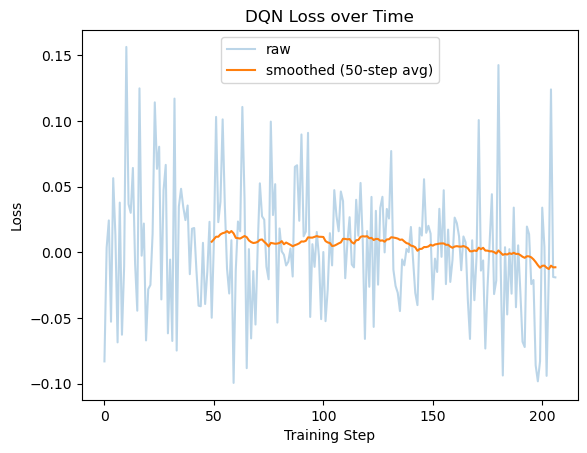

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

smoothed = pd.Series(loss_over_time).rolling(window=50).mean()

plt.plot(loss_over_time, alpha=0.3, label="raw")
plt.plot(smoothed, label="smoothed (50-step avg)")
plt.xlabel("Training Step")
plt.ylabel("Loss")
plt.title("REINFORCE Loss over Time")
plt.legend()
plt.show()

It should do terribly! :-)

In this environment everything is really bad (large negative rewards) or maybe if we are lucky only slightly bad (small negative rewards).

What we need to do is give our agent some sense of how it's doing in relative terms. Am i doing better than before?



### REINFORCE with baseline

Let's add another model that will model the expected value of each state. That way when the agent is interacting with the environment it can test if an action can beat the expected value of a particular state. 

In [37]:

base_env = GymEnv("Pendulum-v1")

env = TransformedEnv(
    base_env,
    Compose(
        # normalize observations
        ObservationNorm(in_keys=["observation"]),
        DoubleToFloat(),
        StepCounter(),
        RewardScaling(loc=0, scale=0.01)
    ),
)
env.transform[0].init_stats(num_iter=1000, reduce_dim=0, cat_dim=0)

#### Policy

Let's keep our policy the same

In [38]:
from torchrl.modules import ProbabilisticActor, TanhNormal
from torchrl.modules import NormalParamExtractor

num_cells = 32
device = "cpu"

actor_net = nn.Sequential(
    nn.LazyLinear(num_cells, device=device),
    nn.Tanh(),
    nn.LazyLinear(num_cells, device=device),
    nn.Tanh(),
    nn.LazyLinear(num_cells, device=device),
    nn.Tanh(),
    nn.LazyLinear(2 * env.action_spec.shape[-1], device=device),
    NormalParamExtractor(),
)

policy_module = TensorDictModule(
    actor_net, in_keys=["observation"], out_keys=["loc", "scale"]
)

policy_module = ProbabilisticActor(
    module=policy_module,
    spec=env.action_spec,
    in_keys=["loc", "scale"],
    distribution_class=TanhNormal,
    distribution_kwargs={
        "low": env.action_spec_unbatched.space.low,
        "high": env.action_spec_unbatched.space.high,
    },
    return_log_prob=True,
)

#### Value function

Then let's create a value function to estimate the value of each state. Where states are defined by the observations.

In [45]:
n_obs = env.observation_spec["observation"].shape[-1]
nodes = 32

#create a model: takes observations as inputs, and outputs categorical actions
model = nn.Sequential(
    nn.Linear(n_obs,nodes),
    nn.ReLU(),
    nn.Linear(nodes,nodes),
    nn.ReLU(),
    nn.Linear(nodes, 1),
)

#go from observations to logits using the model
value_net = TensorDictModule(
    model,
    in_keys=["observation"],
    out_keys=["state_value"],          
)


#### Training

In [49]:

from torchrl.collectors import SyncDataCollector
from torchrl.data import LazyTensorStorage, ReplayBuffer, SamplerWithoutReplacement
from torchrl.record import CSVLogger
import torch.nn.functional as F
from torchrl.envs import RewardScaling


logger = CSVLogger(exp_name="my_exp")

frames_per_batch = 1000
total_frames = 1_000_000
gamma = 0.95


collector = SyncDataCollector(
    env,
    policy_module,
    frames_per_batch=frames_per_batch,
    total_frames=total_frames,
    split_trajs=False,
    device=device,
)

#optim = RMSprop(loss_fn.parameters(), lr=0.0007, eps=1e-5)

#update both the value and policy networks
#optim = Adam(list(value_net.parameters())+ list(policy_module.parameters()), lr=0.0007, eps=1e-5)
optim_policy = Adam(policy_module.parameters(), lr=3e-4)
optim_value  = Adam(value_net.parameters(),     lr=1e-3)

#agent-environment interactions!
for data in collector:
    
    #collect the data
    obs    = data["observation"]
    next_obs = data["next", "observation"]
    reward = data["next", "reward"].squeeze(-1)
    done   = data["next", "done"].squeeze(-1).float()

    #reward_mean = 20 #reward.mean()
    #reward_std  = 5 #reward.std() + 1e-8
    #reward_norm = (reward - reward_mean) / reward_std

    #get current estimated value of state
    v_s = value_net(data)["state_value"].squeeze(-1) 
    

    #calculate the td-target
    with torch.no_grad():

        #get current estimated value of state in the next step
        v_s_next = value_net(data["next"])["state_value"].squeeze(-1)

        #then get the target (observed reward + discounted value of the next state)
        target = reward + gamma * (1.0 - done) * v_s_next

    # Advantage estimate
    advantage = (target - v_s).detach()  # detach so actor loss doesn't affect critic. Use value of state without having to backpropogate through the value net from the policy net...
    advantage = (advantage - advantage.mean()) / (advantage.std() + 1e-8)  # 

    # value loss
    loss_value = F.mse_loss(v_s, target)

    # policy loss
    dist = policy_module.get_dist(data) #get the tanhnormal distribution
    log_probs = dist.log_prob(data["action"]).squeeze() #see where the action falls in terms of tanhnormal
    
    entropy = -log_probs.mean()
    
    #entropy = -log_probs.mean()
    loss_action = -(log_probs * advantage).mean() - 0.01 * entropy #note: advantage here not returns anymore...
    

    #Combined loss
    loss = loss_action + 0.5 * loss_value

    #upaet policy
    optim_policy.zero_grad()
    loss_action.backward(retain_graph=True)
    torch.nn.utils.clip_grad_norm_(policy_module.parameters(), 0.5)
    optim_policy.step()

    #update value
    optim_value.zero_grad()
    loss_value.backward()
    torch.nn.utils.clip_grad_norm_(value_net.parameters(), 0.5)
    optim_value.step()

    #logging
    logger.log_scalar("loss_value", loss_value.item())
    logger.log_scalar("loss_policy", loss_action.item())

    print(
    f"Batch {collector._frames // frames_per_batch:4d} | "
    f"Reward: {reward.mean().item():+7.3f} | "
    f"Value Loss: {loss_value:7.3f} | "
    f"Policy Loss: {loss_action:+7.3f} | "
    f"Target: {target.mean().item():+6.3f} | "   # should track reward scale
    f"TD error: {(target - v_s).mean().item():+6.3f} | "  # should shrink over time
    f"Value Est: {v_s.mean().item():+6.3f}"
    )
    

/home/titan2/data/conda-envs/torchrl_latest/lib/python3.12/site-packages/torchrl/collectors/_base.py:1045: DeprecationWarning: SyncDataCollector has been deprecated and will be removed in v0.13. Please use Collector instead.
  warnings.warn(


Batch    1 | Reward:  -0.080 | Value Loss:   0.034 | Policy Loss:  +0.029 | Target: -2.440 | TD error: +0.055 | Value Est: -2.495
Batch    2 | Reward:  -0.077 | Value Loss:   0.034 | Policy Loss:  +0.022 | Target: -2.363 | TD error: +0.054 | Value Est: -2.418
Batch    3 | Reward:  -0.075 | Value Loss:   0.031 | Policy Loss:  +0.018 | Target: -2.297 | TD error: +0.051 | Value Est: -2.348
Batch    4 | Reward:  -0.071 | Value Loss:   0.031 | Policy Loss:  +0.033 | Target: -2.228 | TD error: +0.052 | Value Est: -2.279
Batch    5 | Reward:  -0.066 | Value Loss:   0.041 | Policy Loss:  +0.019 | Target: -2.149 | TD error: +0.052 | Value Est: -2.201
Batch    6 | Reward:  -0.077 | Value Loss:   0.027 | Policy Loss:  +0.001 | Target: -2.165 | TD error: +0.043 | Value Est: -2.208
Batch    7 | Reward:  -0.078 | Value Loss:   0.025 | Policy Loss:  +0.014 | Target: -2.134 | TD error: +0.038 | Value Est: -2.172
Batch    8 | Reward:  -0.075 | Value Loss:   0.034 | Policy Loss:  -0.011 | Target: -2.059

Let's visualize the results!